This notebook estimates optical aberrations in the GSpec setup according to the coupling achieved into the single mode fiber with the single aperture setup.

# IMPORTS

In [182]:
import numpy as np

import scipy.optimize

import matplotlib.pyplot as plt
from matplotlib import font_manager
font_dir = ['/home/paiasnodkar.1/fonts']
for font in font_manager.findSystemFonts(font_dir):
    font_manager.fontManager.addfont(font)

import astropy.units as u

import aotools

fontweight = 300
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Mulish']
plt.rcParams["font.weight"] = fontweight
plt.rcParams['axes.labelweight'] = 1.3*fontweight
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.titlesize'] = 22
plt.rc('text.latex', preamble=r'\usepackage{cmbright}')

# FUNCTIONS

In [103]:
# Define intensity distribution from electric field
I = lambda E: np.absolute(E)**2

# Define electric field transformation from object to image plane
def C(U, return_axes=False, pupil_num_x=None, pupil_num_y=None, beam_diam=None, pupil_dim_x=None, 
      pupil_dim_y=None, f=None, wav_0=None):
    ''' Transforms electric field from object to image plane
        Inputs:
        - U: numpy 2D array of electric field in object plane
        - x_samples, y_samples: numpy 1D arrays of x/y-values being sampled
        - return_freq: returns FFT frequencies when True
        Outputs:
        - I: numpy 2D array of electric field in image planet
        - X, Y: numpy 2D arrays of x/y frequencies being sampled; only returned when return_freq=True
    '''
    I = np.fft.fft2(np.fft.ifftshift(U)) # shift zero frequency component to center of spectrum
    I = np.fft.fftshift(I) # shift back
    if return_axes:
        ratio_x, ratio_y = beam_diam/pupil_dim_x, beam_diam/pupil_dim_y
        X = f * (wav_0/beam_diam) * ratio_x * np.linspace(-pupil_num_x/2., pupil_num_x/2., pupil_num_x+1)
        Y = f * (wav_0/beam_diam) * ratio_y * np.linspace(-pupil_num_y/2., pupil_num_y/2., pupil_num_y+1)
        return I, X.to(u.mm), Y.to(u.mm)
    else:
        return I

# PUPIL PLANE

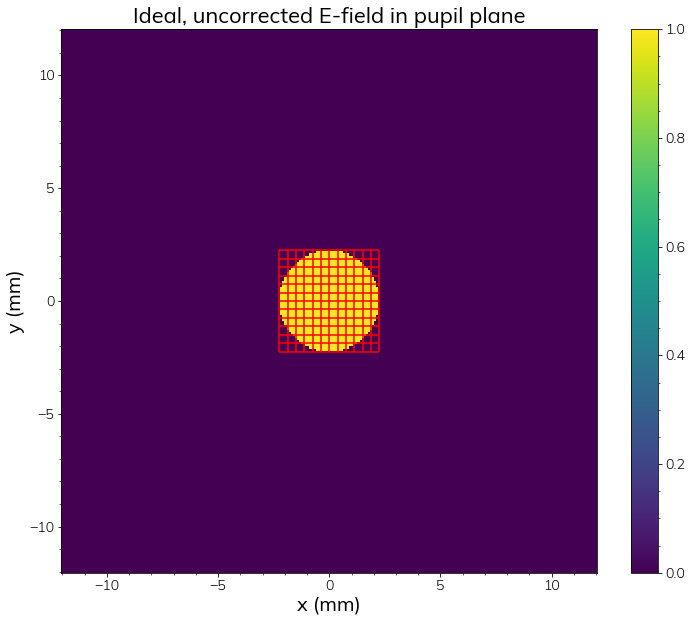

In [159]:
# System properties
f = 20 * u.mm # focal length
# d = 200 * u.mm # distance between lens and image
wav_0 = 635 * u.nm # laser beam wavelength
DM_dim_x, DM_dim_y = 4.5 * u.mm, 4.5 * u.mm # width and height of deformable mirror in mm
DM_num_x, DM_num_y = 12, 12 # number of actuators along width and height of deformable mirror
DM_act_x, DM_act_y = DM_dim_x/DM_num_x, DM_dim_y/DM_num_y # actuator size in mm
DM_stroke = 1.5 * u.micron # maximum physical range of DM actuators
cam_dim_x, cam_dim_y = 4.76 * u.mm, 3.57 * u.mm # width and height of detector
cam_num_x, cam_num_y = 1024, 768 # number of pixels along width and height of camera
beam_diam = 4.5 * u.mm; beam_rad = beam_diam/2. # Diameter of beam
MFD = 4.5*u.micron # mode field diameter of single mode fiber

# Set up pupil plane
N = 2**8
actuator_sample = 4
pupil_dim_x, pupil_dim_y = DM_act_x*N/actuator_sample, DM_act_y*N/actuator_sample
pupil_x, pupil_y = (DM_act_x/actuator_sample)*np.linspace(-N/2, N/2, N+1), (DM_act_y/actuator_sample)*np.linspace(-N/2, N/2, N+1)
pupil_grid_x, pupil_grid_y = np.meshgrid(pupil_x, pupil_y)
DM_pixels_x, DM_pixels_y = actuator_sample*DM_num_x, actuator_sample*DM_num_y
DM_edges_x = np.arange(-DM_dim_x.value/2, DM_dim_x.value/2 + DM_act_x.value, DM_act_x.value) * u.mm
DM_edges_y = np.arange(-DM_dim_y.value/2, DM_dim_y.value/2 + DM_act_y.value, DM_act_y.value) * u.mm
pupil_mid = int(N/2 + 1)

def pupil_beam(diam):
    A = np.zeros((N+1, N+1))
    A[(pupil_grid_x**2 + pupil_grid_y**2) < (diam/2)**2] = 1 # Circular aperture
    return A

A = pupil_beam(beam_diam)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(A)), np.max(np.absolute(A))]
im = ax.pcolormesh(pupil_x.value, pupil_y.value, np.absolute(A), vmin=vrange[0], vmax=vrange[1])
ax.hlines(DM_edges_y.value, -DM_dim_x.value/2, DM_dim_x.value/2, color='r')
ax.vlines(DM_edges_x.value, -DM_dim_y.value/2, DM_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Ideal, uncorrected E-field in pupil plane')
fig.colorbar(im, ax=ax)
plt.show()

# FOCAL PLANE

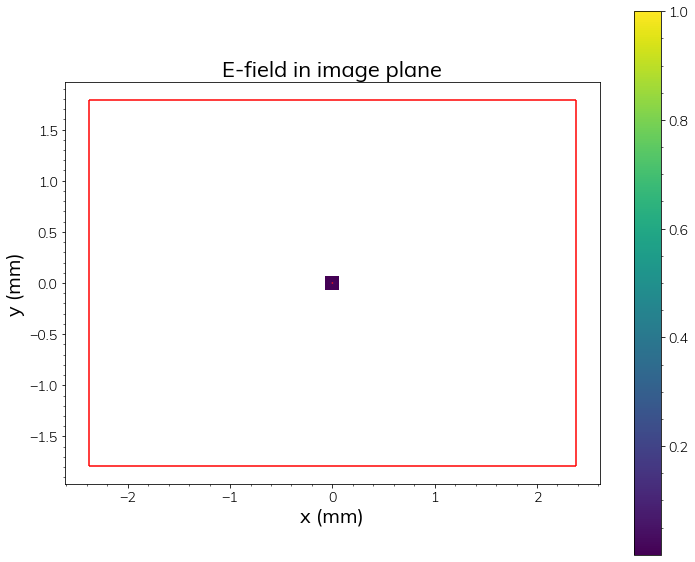

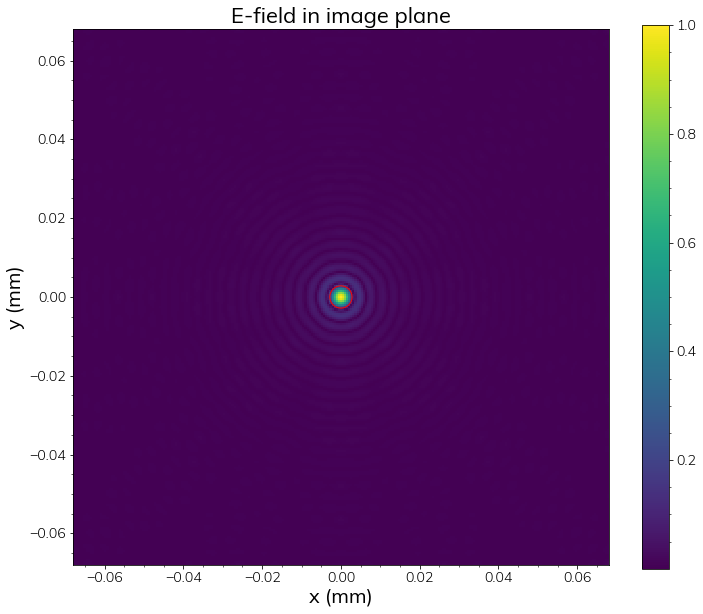

In [160]:
# Set up camera in image plane
cam_el_x, cam_el_y = cam_dim_x/cam_num_x, cam_dim_y/cam_num_y # camera pixel size in mm
cam_edges_x = np.arange(-cam_dim_x.value/2, cam_dim_x.value/2 + cam_el_x.value, cam_el_x.value) * u.mm
cam_edges_y = np.arange(-cam_dim_y.value/2, cam_dim_y.value/2 + cam_el_y.value, cam_el_y.value) * u.mm

def focal_beam(diam, A):
    E_A, X, Y = C(A, True, N, N, diam, pupil_dim_x,
                   pupil_dim_y, f, wav_0)
    E_A = E_A/np.max(E_A)
    return E_A, X, Y

E_A, X, Y = focal_beam(beam_diam, A)
PSF = (wav_0 * f/beam_diam).to(u.mm)
# X, Y, PSF = X*2.4, Y*2.4, PSF*2.4

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [np.min(np.absolute(E_A)), np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(E_A), vmin=vrange[0], vmax=vrange[1])
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.hlines([cam_edges_y[0].value, cam_edges_y[-1].value], -cam_dim_x.value/2, cam_dim_x.value/2, color='r')
ax.vlines([cam_edges_x[0].value, cam_edges_x[-1].value], -cam_dim_y.value/2, cam_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane')
fig.colorbar(im, ax=ax)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [np.min(np.absolute(E_A)), np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(E_A), vmin=vrange[0], vmax=vrange[1])
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane')
fig.colorbar(im, ax=ax)
plt.show()

# MODE FIELD OF OUTPUT SINGLE MODE FIBER

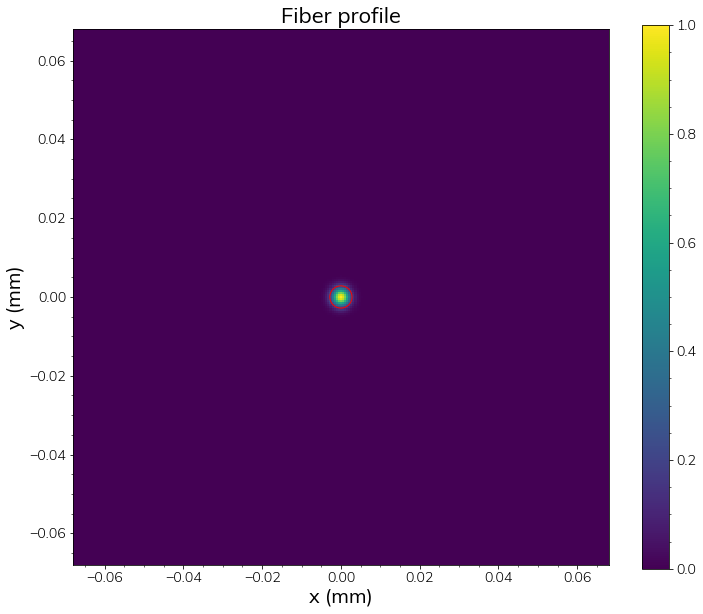

Coupling:  0.21719248291126353


In [176]:
gaussian = lambda x, amp, mu, sigma: amp * np.exp(-((x-mu)**2 / (2.0 * sigma**2)))
coupling = lambda E, fiber: np.absolute(np.sum(E*fiber))**2/np.absolute(np.sum(E))**2

def gaussian_filter(kernel_size, amp=1, mu=0, sigma=1):
 
    # Initializing value of x,y as grid of kernel size
    # in the range of kernel size
 
    x, y = np.meshgrid(np.linspace(-1, 1, kernel_size),
                       np.linspace(-1, 1, kernel_size))
    dst = np.sqrt(x**2+y**2)
 
    # Calculating Gaussian filter
    gauss = gaussian(dst, amp, mu, sigma)
    return gauss

sigma = MFD/(2*np.sqrt(2))
sigma_focal = (sigma/max(X)).to(u.dimensionless_unscaled)
fiber = gaussian_filter(N+1, sigma=sigma_focal)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [np.min(np.absolute(fiber)), np.max(np.absolute(fiber))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(fiber), vmin=vrange[0], vmax=vrange[1])
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Fiber profile')
fig.colorbar(im, ax=ax)
plt.show()

print('Coupling: ', coupling(E_A, fiber))

# Incorporate aberrations

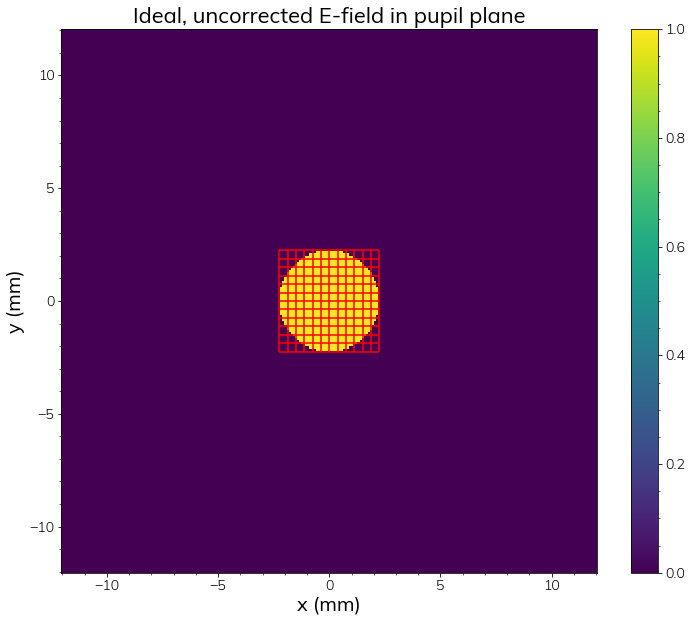

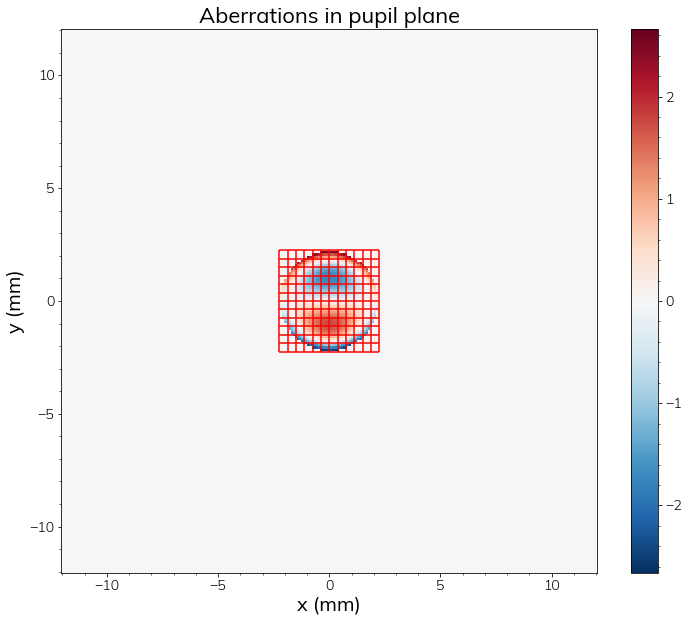

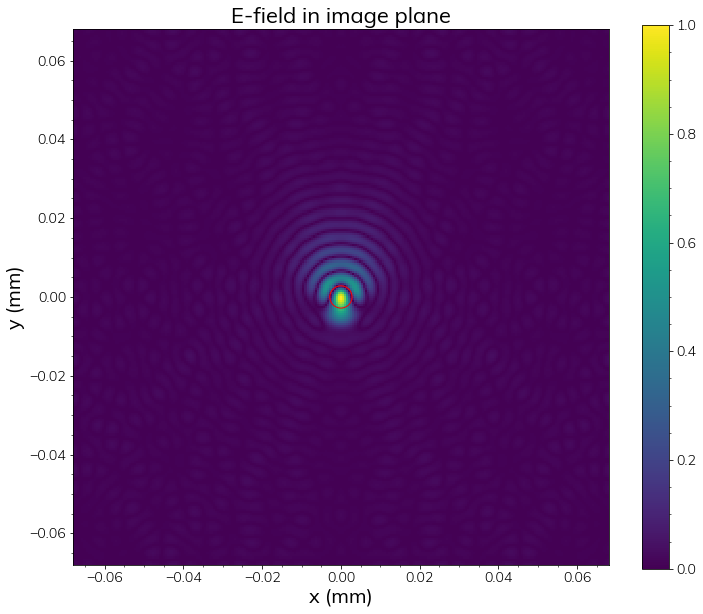

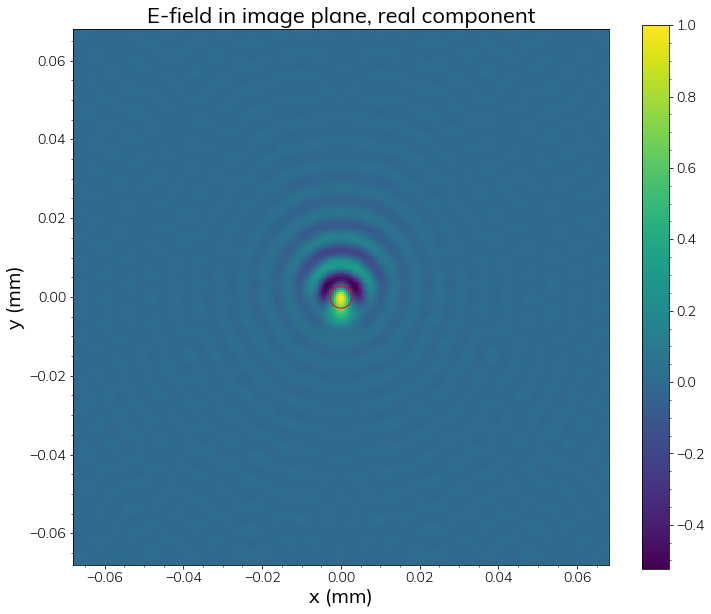

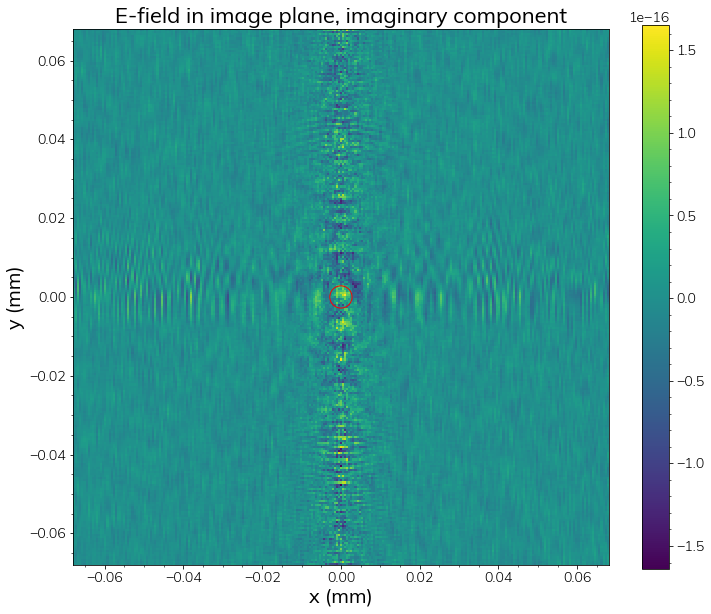

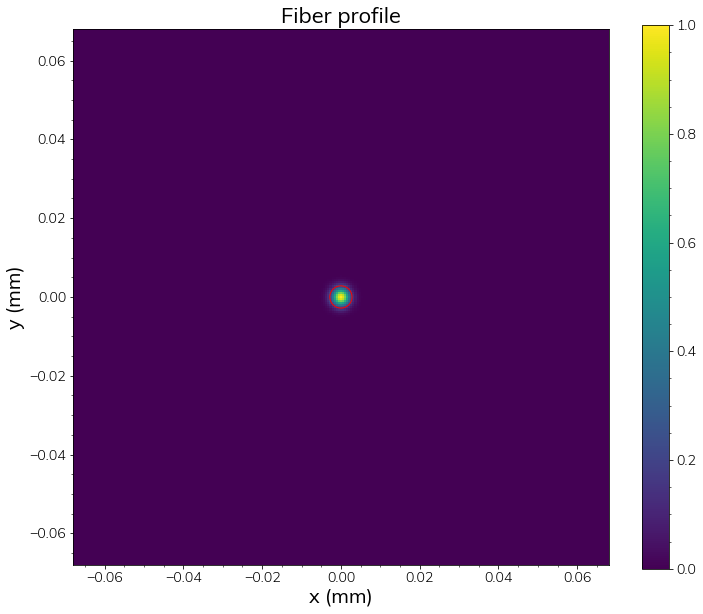

Coupling:  0.21719248291126353


In [177]:
### Beam ###

# Ideal
beam_diam = 4.5 * u.mm
A = pupil_beam(beam_diam)

# Aberrations
aberration = lambda alpha, beta: np.exp(alpha + 1j*beta) # Aberrations
in_beam, = np.where(abs(pupil_x) < beam_diam/2.)
in_beam_min, in_beam_max = np.min(in_beam), np.max(in_beam)
alpha = np.zeros_like(A)
n, m = 3, -1
beta_in_beam = aotools.functions.zernike.zernike_nm(n, m, len(in_beam))
beta = np.zeros_like(A)
beta[in_beam_min:in_beam_max+1, in_beam_min:in_beam_max+1] = beta_in_beam
aber = aberration(alpha, beta)
A_aber = A*aber
E_A, X, Y = focal_beam(beam_diam, A_aber)
PSF = (wav_0 * f/beam_diam).to(u.mm)

### Fiber ###
sigma = MFD/(2*np.sqrt(2))
sigma_focal = (sigma/max(X)).to(u.dimensionless_unscaled)
fiber = gaussian_filter(N+1, sigma=sigma_focal)

# Beam in pupil plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [0, np.max(np.absolute(A))]
im = ax.pcolormesh(pupil_x.value, pupil_y.value, np.absolute(A), vmin=vrange[0], vmax=vrange[1])
ax.hlines(DM_edges_y.value, -DM_dim_x.value/2, DM_dim_x.value/2, color='r')
ax.vlines(DM_edges_x.value, -DM_dim_y.value/2, DM_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Ideal, uncorrected E-field in pupil plane')
fig.colorbar(im, ax=ax)
plt.show()

# Aberrations in pupil plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
im = ax.pcolormesh(pupil_x.value, pupil_y.value, beta, cmap='RdBu_r')#, vmin=vrange[0], vmax=vrange[1])
ax.hlines(DM_edges_y.value, -DM_dim_x.value/2, DM_dim_x.value/2, color='r')
ax.vlines(DM_edges_x.value, -DM_dim_y.value/2, DM_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Aberrations in pupil plane')
fig.colorbar(im, ax=ax)
plt.show()

# Beam in focal plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [0, np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(E_A), vmin=vrange[0], vmax=vrange[1])
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane')
fig.colorbar(im, ax=ax)
plt.show()

# Beam in focal plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [0, np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.real(E_A))
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane, real component')
fig.colorbar(im, ax=ax)
plt.show()

# Beam in focal plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [0, np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.imag(E_A))
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane, imaginary component')
fig.colorbar(im, ax=ax)
plt.show()

# SMF profile
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [np.min(np.absolute(fiber)), np.max(np.absolute(fiber))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(fiber), vmin=vrange[0], vmax=vrange[1])
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Fiber profile')
fig.colorbar(im, ax=ax)
plt.show()

print('Coupling: ', coupling(E_A, fiber))

# Determine amplitude of aberration necessary to account for deviation from ideal coupling

Zernike mode: 3, -1
Aberration amplitude:  [0.46108688]
Coupling:  0.4999999999999998


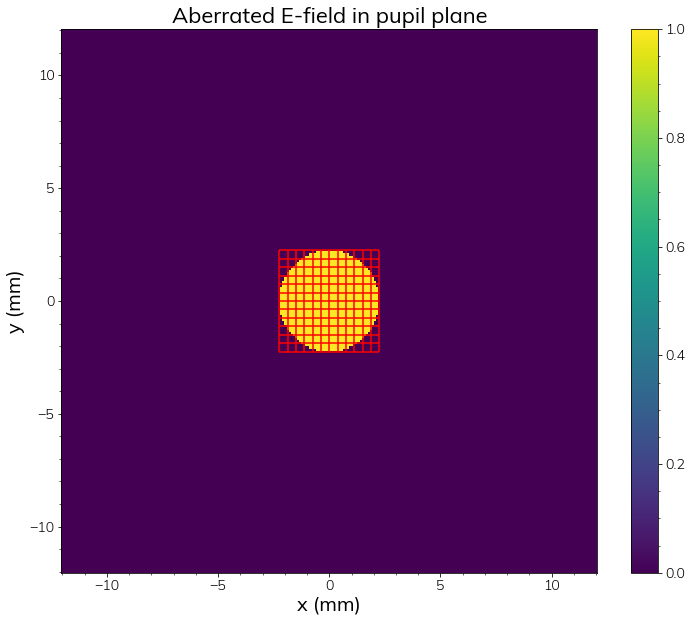

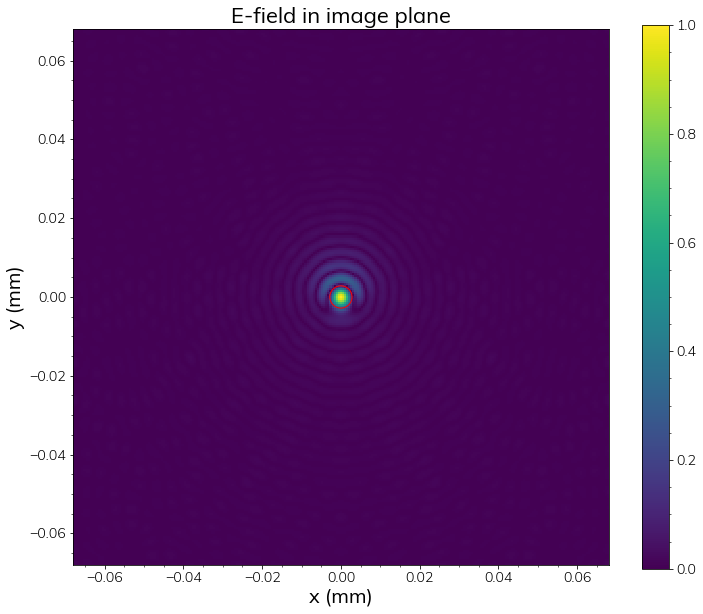

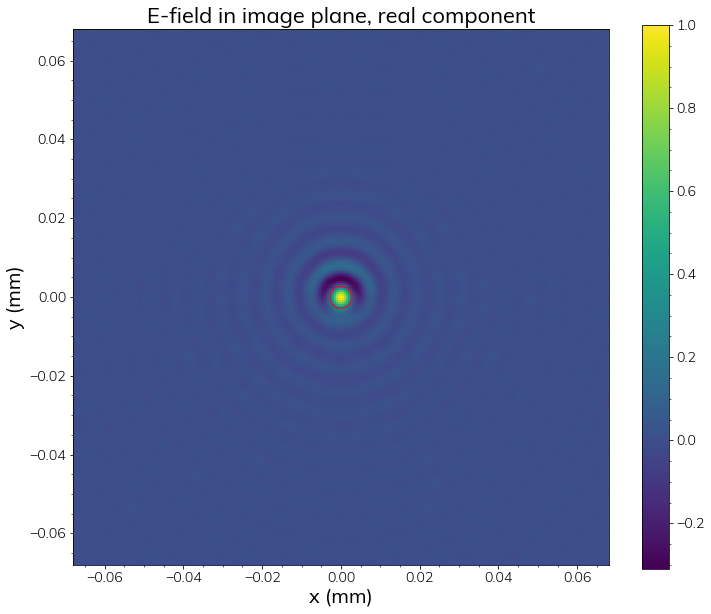

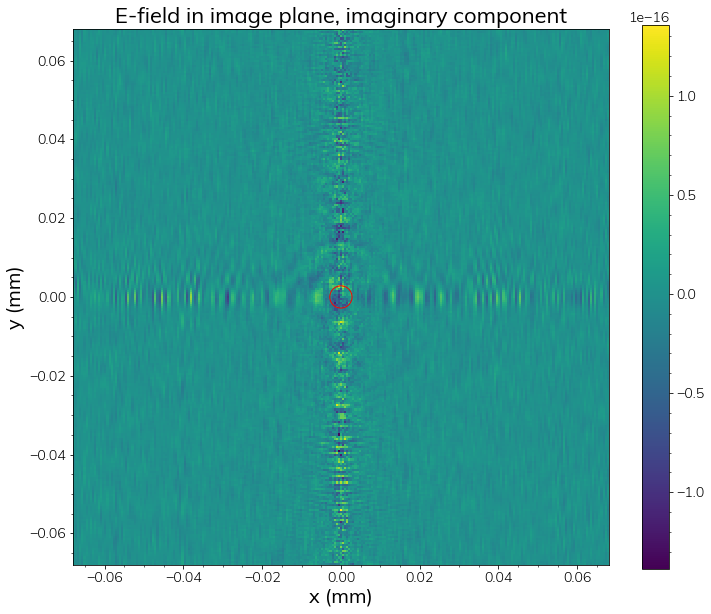

In [192]:
# Ideal
beam_diam = 4.5 * u.mm
# Zernike modes: (3, +/-1) for coma
n, m = 3, -1

def E_aberration(diam, n, m, amp_aber):
    A = pupil_beam(beam_diam)
    in_beam, = np.where(abs(pupil_x) < diam/2.)
    in_beam_min, in_beam_max = np.min(in_beam), np.max(in_beam)
    alpha = np.zeros_like(A)
    beta_in_beam = amp_aber * aotools.functions.zernike.zernike_nm(n, m, len(in_beam))
    beta = np.zeros_like(A)
    beta[in_beam_min:in_beam_max+1, in_beam_min:in_beam_max+1] = beta_in_beam
    aber = aberration(alpha, beta)
    A_aber = A*aber
    E_aber, X, Y = focal_beam(diam, A_aber)
    PSF = (wav_0 * f/diam).to(u.mm)
    return A_aber, E_aber, X, Y, PSF


fit_aber = lambda amp_aber: coupling(E_aberration(beam_diam, n, m, amp_aber)[1], fiber) - 0.5
res = scipy.optimize.root(fit_aber, [0.1], tol=1e-9)
amp_aber = res.x
A_aber, E_aber, X, Y, PSF = E_aberration(beam_diam, n, m, amp_aber)
print('Zernike mode: %d, %d'%(n, m))
print('Aberration amplitude: ', amp_aber)
print('Coupling: ', coupling(E_aberration(beam_diam, n, m, amp_aber)[1], fiber))

# Beam in pupil plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [0, np.max(np.absolute(A))]
im = ax.pcolormesh(pupil_x.value, pupil_y.value, np.absolute(A_aber), vmin=vrange[0], vmax=vrange[1])
ax.hlines(DM_edges_y.value, -DM_dim_x.value/2, DM_dim_x.value/2, color='r')
ax.vlines(DM_edges_x.value, -DM_dim_y.value/2, DM_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Aberrated E-field in pupil plane')
fig.colorbar(im, ax=ax)
plt.show()
# Beam in focal plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [0, np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(E_aber), vmin=vrange[0], vmax=vrange[1])
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane')
fig.colorbar(im, ax=ax)
plt.show()
# Beam in focal plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [0, np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.real(E_aber))
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane, real component')
fig.colorbar(im, ax=ax)
plt.show()
# Beam in focal plane
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [0, np.max(np.absolute(E_A))]
im = ax.pcolormesh(X.value, Y.value, np.imag(E_aber))
circle = plt.Circle((0, 0), PSF.value, color='r', fill=False)
ax.add_patch(circle)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane, imaginary component')
fig.colorbar(im, ax=ax)
plt.show()